# Optimizaiton

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

plt.rcParams["font.family"] = "Arial" 

In [2]:
root_dir = '/data/MQ_dev_tests_2'
fig_dir = '/figures/mq_dev_analysis_figs/'

In [ ]:
dfs = []

for subdir, _, files in os.walk(root_dir):
    for file in files:
        if file == 'msms.txt':
            file_path = os.path.join(subdir, file)
            # Get the parent directory one level up
            parent_folder = os.path.basename(os.path.dirname(subdir))
            print(file_path)
            df = pd.read_csv(file_path, delimiter="\t")
            
            new_columns = {}
            for col in df.columns:
                if 'SUMO2/3' in col:
                    new_col_name = 'SUMO2/3' + col.split('SUMO2/3', 1)[1]
                    new_columns[col] = new_col_name
            
            df.rename(columns=new_columns, inplace=True)
            df['Dataset'] = parent_folder
            print(parent_folder)
            print("adding")
            dfs.append(df)

big_df = pd.concat(dfs, ignore_index=True)

# big_df.to_csv('/path/to/save/combined_file.txt', sep="\t", index=False)

In [4]:
big_df = big_df[big_df['Contaminant'] != '+']
big_df['Reverse'].fillna('-', inplace=True)

In [5]:
# sumo dataset 
df_sumo = big_df[big_df['SUMO2/3-DVFQQQTGG'] == 1] 
df_no_sumo = big_df[big_df['SUMO2/3-DVFQQQTGG'] == 0] 

df_sumo_more = big_df[big_df['SUMO2/3-DVFQQQTGG'] > 1] 

# filtered pep 0.01
PEP_sumo_df = df_sumo[df_sumo['PEP'] < 0.01]
PEP05_sumo_df = df_sumo[df_sumo['PEP'] < 0.05]

In [6]:
# unique sites and peptides  
df_sumo_unique = df_sumo.groupby('Dataset').apply(lambda x: x.drop_duplicates(subset=['Modified sequence'], keep='last')).reset_index(drop=True)
df_unique = df_no_sumo.groupby('Dataset').apply(lambda x: x.drop_duplicates(subset=['Modified sequence'], keep='last')).reset_index(drop=True)

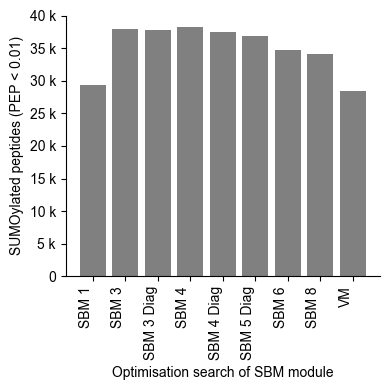

In [7]:
filtered_big_df = df_sumo[df_sumo['Reverse'] != '+']
filtered_counts = filtered_big_df[filtered_big_df['PEP'] < 0.01].groupby('Dataset').size()

fig, ax = plt.subplots(figsize=(4, 4))
bars = ax.bar(filtered_counts.index, filtered_counts.values, color='grey')

#for bar in bars:
#    height = bar.get_height()
#    ax.text(bar.get_x() + bar.get_width() / 2.0, height, '%d' % int(height), ha='center', va='bottom')

ax.set_xlabel('Optimisation search of SBM module')
ax.set_ylabel('SUMOylated peptides (PEP < 0.01)')
ax.set_title('')
ax.set_xticks(filtered_counts.index) 
ax.set_xticklabels(filtered_counts.index, ha='right',rotation=90)  # rotation=45,  
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.set_ylim(0, 40000)
ax.yaxis.set_major_formatter(ticker.EngFormatter())
plt.tight_layout()
plt.savefig(fig_dir + "SBM_optimisation_0.01.pdf")
plt.show()


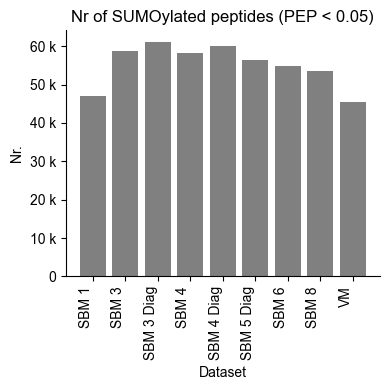

In [25]:
filtered_big_df = df_sumo[df_sumo['Reverse'] != '+']
filtered_counts = filtered_big_df[filtered_big_df['PEP'] < 0.05].groupby('Dataset').size()

fig, ax = plt.subplots(figsize=(4, 4))
bars = ax.bar(filtered_counts.index, filtered_counts.values, color='grey')

#for bar in bars:
#    height = bar.get_height()
#    ax.text(bar.get_x() + bar.get_width() / 2.0, height, '%d' % int(height), ha='center', va='bottom')

ax.set_xlabel('Dataset')
ax.set_ylabel('Nr.')
ax.set_title('Nr of SUMOylated peptides (PEP < 0.05)')
ax.set_xticks(filtered_counts.index) 
ax.set_xticklabels(filtered_counts.index, ha='right',rotation=90)  # rotation=45, 
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.yaxis.set_major_formatter(ticker.EngFormatter())

plt.tight_layout()
plt.tight_layout()
plt.savefig(fig_dir + "SBM_optimisation_0.05.pdf")

plt.show()

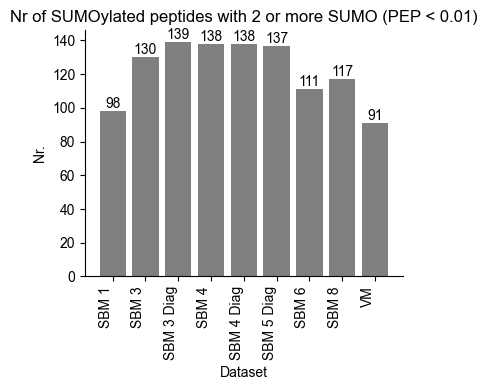

In [9]:
filtered_big_df = df_sumo_more[df_sumo_more['Reverse'] != '+']
filtered_counts = filtered_big_df[filtered_big_df['PEP'] < 0.01].groupby('Dataset').size()

fig, ax = plt.subplots(figsize=(4, 4))
bars = ax.bar(filtered_counts.index, filtered_counts.values, color='grey')

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2.0, height, '%d' % int(height), ha='center', va='bottom')

ax.set_xlabel('Dataset')
ax.set_ylabel('Nr.')
ax.set_title('Nr of SUMOylated peptides with 2 or more SUMO (PEP < 0.01)')
ax.set_xticks(filtered_counts.index) 
ax.set_xticklabels(filtered_counts.index, ha='right',rotation=90)  # rotation=45,  
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.yaxis.set_major_formatter(ticker.EngFormatter())
plt.tight_layout()
plt.show()


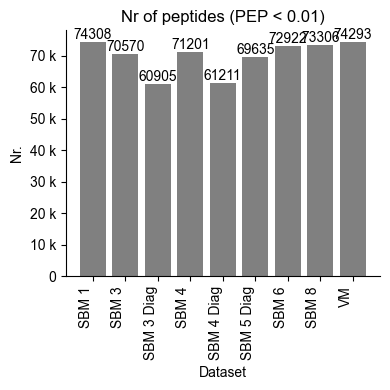

In [10]:
filtered_big_df_no_sumo = df_no_sumo[df_no_sumo['Reverse'] != '+']
filtered_counts_no_sumo = filtered_big_df_no_sumo[filtered_big_df_no_sumo['PEP'] < 0.01].groupby('Dataset').size()

fig, ax = plt.subplots(figsize=(4, 4))
bars = ax.bar(filtered_counts_no_sumo.index, filtered_counts_no_sumo.values, color='grey')

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2.0, height, '%d' % int(height), ha='center', va='bottom')

ax.set_xlabel('Dataset')
ax.set_ylabel('Nr.')
ax.set_title('Nr of peptides (PEP < 0.01)')
ax.set_xticks(filtered_counts.index) 
ax.set_xticklabels(filtered_counts.index, ha='right',rotation=90)  # rotation=45,  
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.yaxis.set_major_formatter(ticker.EngFormatter())
plt.tight_layout()
plt.show()

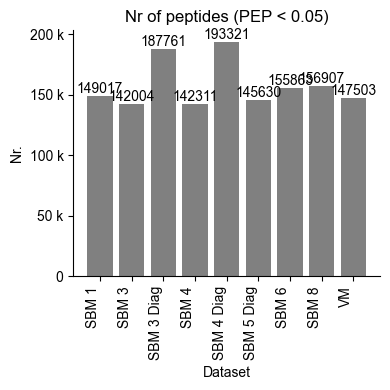

In [26]:
filtered_big_df_no_sumo = df_no_sumo[df_no_sumo['Reverse'] != '+']
filtered_counts_no_sumo = filtered_big_df_no_sumo[filtered_big_df_no_sumo['PEP'] < 0.05].groupby('Dataset').size()

fig, ax = plt.subplots(figsize=(4, 4))
bars = ax.bar(filtered_counts_no_sumo.index, filtered_counts_no_sumo.values, color='grey')

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2.0, height, '%d' % int(height), ha='center', va='bottom')

ax.set_xlabel('Dataset')
ax.set_ylabel('Nr.')
ax.set_title('Nr of peptides (PEP < 0.05)')
ax.set_xticks(filtered_counts.index) 
ax.set_xticklabels(filtered_counts.index, ha='right',rotation=90)  #  rotation=45,
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.yaxis.set_major_formatter(ticker.EngFormatter())
plt.tight_layout()
plt.show()

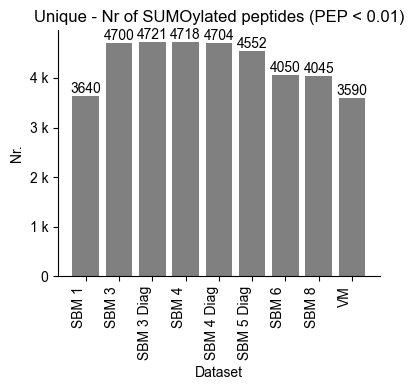

In [12]:
filtered_big_df_unique = df_sumo_unique[df_sumo_unique['Reverse'] != '+']
filtered_counts_unique = filtered_big_df_unique[filtered_big_df_unique['PEP'] < 0.01].groupby('Dataset').size()

fig, ax = plt.subplots(figsize=(4, 4))
bars_un = ax.bar(filtered_counts_unique.index, filtered_counts_unique.values, color='grey')

for bar in bars_un:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2.0, height, '%d' % int(height), ha='center', va='bottom')

ax.set_xlabel('Dataset')
ax.set_ylabel('Nr.')
ax.set_title('Unique - Nr of SUMOylated peptides (PEP < 0.01)')
ax.set_xticks(filtered_counts_unique.index) 
ax.set_xticklabels(filtered_counts_unique.index, ha='right',rotation=90) # rotation=45,  

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.yaxis.set_major_formatter(ticker.EngFormatter())
plt.tight_layout()
plt.savefig("unique_0.01.pdf")
plt.show()

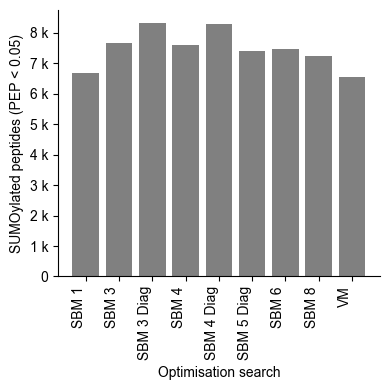

In [30]:
filtered_big_df_unique = df_sumo_unique[df_sumo_unique['Reverse'] != '+']
filtered_counts_unique = filtered_big_df_unique[filtered_big_df_unique['PEP'] < 0.05].groupby('Dataset').size()

fig, ax = plt.subplots(figsize=(4, 4))
bars_un = ax.bar(filtered_counts_unique.index, filtered_counts_unique.values, color='grey')

#for bar in bars_un:
#    height = bar.get_height()
#    ax.text(bar.get_x() + bar.get_width() / 2.0, height, '%d' % int(height), ha='center', va='bottom')

ax.set_xlabel('Optimisation search')
ax.set_ylabel('SUMOylated peptides (PEP < 0.05)')
ax.set_title('')
ax.set_xticks(filtered_counts_unique.index) 
ax.set_xticklabels(filtered_counts_unique.index, ha='right',rotation=90) # rotation=45,  

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.yaxis.set_major_formatter(ticker.EngFormatter())
plt.tight_layout()
plt.savefig(fig_dir + "SBM_opt_unique_0.05.pdf")
plt.show()


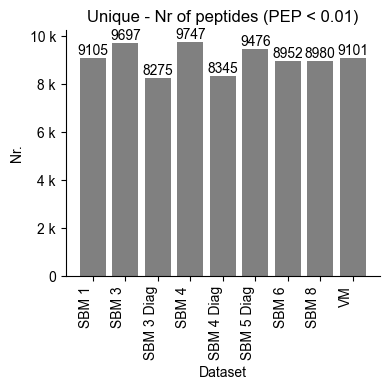

In [14]:
filtered_big_df_unique_peps = df_unique[df_unique['Reverse'] != '+']
filtered_counts_unique_peps = filtered_big_df_unique_peps[filtered_big_df_unique_peps['PEP'] < 0.01].groupby('Dataset').size()

fig, ax = plt.subplots(figsize=(4, 4))
bars_un = ax.bar(filtered_counts_unique_peps.index, filtered_counts_unique_peps.values, color='grey')

for bar in bars_un:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2.0, height, '%d' % int(height), ha='center', va='bottom')

ax.set_xlabel('Dataset')
ax.set_ylabel('Nr.')
ax.set_title('Unique - Nr of peptides (PEP < 0.01)')
ax.set_xticks(filtered_counts_unique.index) 
ax.set_xticklabels(filtered_counts_unique.index, ha='right',rotation=90) # rotation=45,  

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.yaxis.set_major_formatter(ticker.EngFormatter())
plt.tight_layout()
plt.show()

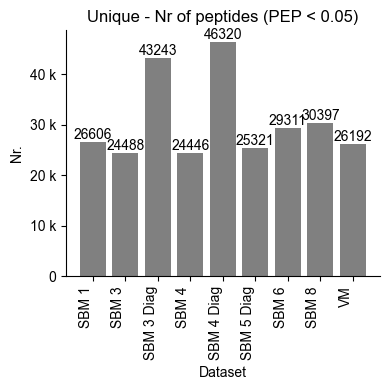

In [15]:
filtered_big_df_unique_peps = df_unique[df_unique['Reverse'] != '+']
filtered_counts_unique_peps = filtered_big_df_unique_peps[filtered_big_df_unique_peps['PEP'] < 0.05].groupby('Dataset').size()

fig, ax = plt.subplots(figsize=(4, 4))
bars_un = ax.bar(filtered_counts_unique_peps.index, filtered_counts_unique_peps.values, color='grey')

for bar in bars_un:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2.0, height, '%d' % int(height), ha='center', va='bottom')

ax.set_xlabel('Dataset')
ax.set_ylabel('Nr.')
ax.set_title('Unique - Nr of peptides (PEP < 0.05)')
ax.set_xticks(filtered_counts_unique.index) 
ax.set_xticklabels(filtered_counts_unique.index, ha='right',rotation=90) # rotation=45,  

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.yaxis.set_major_formatter(ticker.EngFormatter())
plt.tight_layout()
plt.show()

In [16]:
df_to_use = PEP_sumo_df[PEP_sumo_df['Reverse'] != '+']

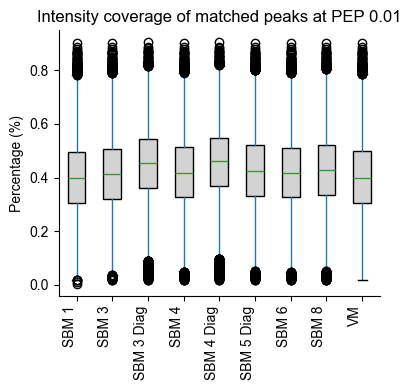

In [17]:
combined_data = df_to_use.pivot(columns='Dataset', values='Intensity coverage')

fig, ax = plt.subplots(figsize=(4, 4))
boxprops = dict(facecolor='lightgrey', color='black')
combined_data.boxplot(ax=ax, widths=0.5, boxprops=boxprops, patch_artist=True)

ax.set_title('Intensity coverage of matched peaks at PEP 0.01')
ax.set_ylabel('Percentage (%)')

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

ax.grid(False)
ax.set_xticklabels(ax.get_xticklabels(), ha='right',rotation=90) # rotation=45,
plt.tight_layout()
plt.savefig("intensity_coverage.pdf")
plt.show()


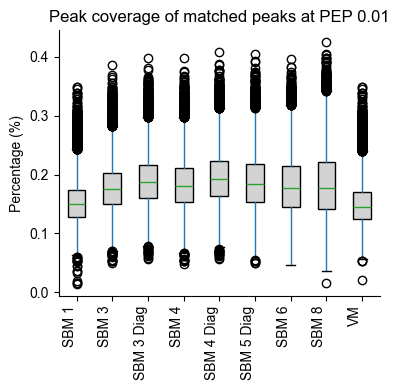

In [18]:
combined_data = df_to_use.pivot(columns='Dataset', values='Peak coverage')

fig, ax = plt.subplots(figsize=(4, 4))
boxprops = dict(facecolor='lightgrey', color='black')
combined_data.boxplot(ax=ax, widths=0.5, boxprops=boxprops, patch_artist=True)

ax.set_title('Peak coverage of matched peaks at PEP 0.01')
ax.set_ylabel('Percentage (%)')
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.grid(False)
ax.set_xticklabels(ax.get_xticklabels(), ha='right',rotation=90) #  rotation=45, 
plt.tight_layout()
plt.savefig(fig_dir + "p_ion_optimisation_matched_peaks.pdf")
plt.show()


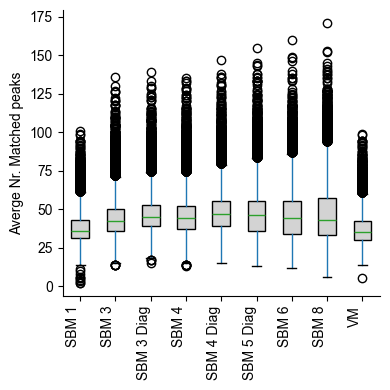

In [19]:
combined_data = df_to_use.pivot(columns='Dataset', values='Number of matches')

fig, ax = plt.subplots(figsize=(4, 4))
boxprops = dict(facecolor='lightgrey', color='black')
combined_data.boxplot(ax=ax, widths=0.5, boxprops=boxprops, patch_artist=True)

ax.set_title('')
ax.set_ylabel('Averge Nr. Matched peaks')
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.grid(False)
ax.set_xticklabels(ax.get_xticklabels(), ha='right',rotation=90) # rotation=45,  
plt.tight_layout()
plt.savefig("matched_peaks.pdf")
plt.show()

In [20]:
sorted_df = big_df.sort_values(by='PEP', ).reset_index(drop=True) 
sorted_df["PEP"]

categories = sorted_df['Dataset'].unique()

# Generate a color map using the tab10 colormap
cmap = plt.get_cmap('tab20')
colors = cmap(range(len(categories)))

# Create a dictionary mapping categories to colors
color_map = dict(zip(categories, colors))

In [21]:
color_map = {'st_0': '#bdc3c7', 'st_1': '#95a5a6', 'st_4': '#7f8c8d', 'st_8': '#414747', 
            'sbm_0': '#245277', 'sbm_1': '#367bb3', 'sbm_2': '#48a3ee', 'sbm_3': '#63b1f1', 
             'sbm_4': '#f8cfaf', 'sbm_5': '#f09f5e', 'sbm_6': '#ec8a3a', 
             'sbm_7': '#b1682c', 'sbm_8': '#76451d', 
            'sbm_4_optimised': '#9b59b6', 'sbm_3_optimised': '#8e44ad', 
             'sbm_3_optimised_diag': '#1abc9c', 'sbm_4_optimised_diag': '#27ae60', 'sbm_5_optimised_diag': '#c0392b'}

In [22]:
color_map = {
    '0': '#ffbc42',
    'VM': '#ffbc42',
    'SBM 0': '#ffbc42',
    'SBM 4': '#2ca02c', 
    'SBM 4 Diag': '#2ca02c', 
    'st':    '#d81159', 
    'Standard':    '#d81159', 
    'Unique Standard':    '#d81159',
    'sbm_3': '#73d2de', 
    'SBM 3': '#73d2de', 
    'SBM 3 Diag': '#73d2de', 
    'MQ SBM3 Percolator': '#73d2de', 
    'sbm3': '#73d2de',
    'Unique SBM 3': '#73d2de',
    'sbm_8': '#218380' ,
    'sbm8': '#218380',
    'SBM 8': '#218380', 
    'SBM 1': '#218380', 
    'SBM 5 Diag': '#218380', 
    'SBM 6': '#ffbc42' 
}

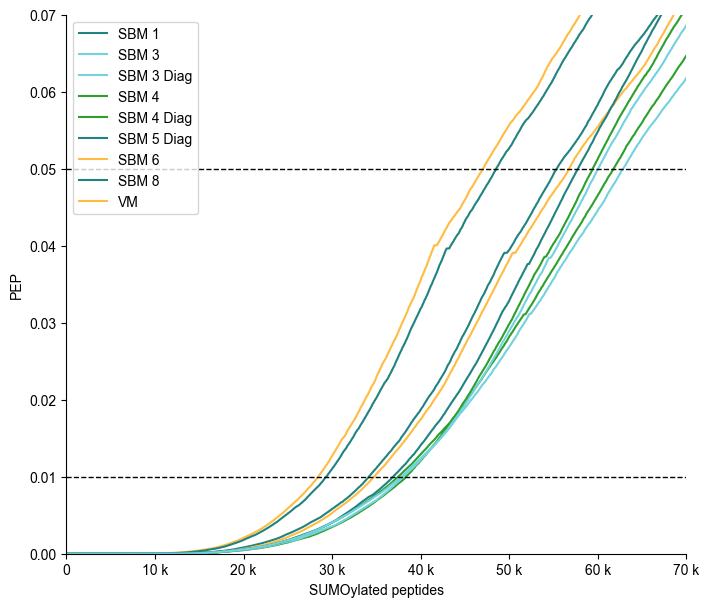

In [23]:
fig, ax = plt.subplots(figsize=(8, 7))

for group in categories:
    group_data = df_sumo[df_sumo['Dataset'] == group]
    sorted_df = group_data.sort_values(by='PEP').reset_index(drop=True)
    ax.plot(sorted_df.index, sorted_df['PEP'], 
            color=color_map[group], label=group)

ax.axhline(y=0.01, color='black', linestyle='--', linewidth=1)
ax.axhline(y=0.05, color='black', linestyle='--', linewidth=1)

ax.set_ylim(0, 0.07)
ax.set_xlim(0, 70000)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.xaxis.set_major_formatter(ticker.EngFormatter())

# get the labels in alphabetical order 
handles, labels = plt.gca().get_legend_handles_labels()
sorted_labels_handles = sorted(zip(labels, handles))
labels, handles = zip(*sorted_labels_handles)
plt.legend(handles, labels, loc='upper left')

ax.set_title('')
ax.set_xlabel('SUMOylated peptides')
ax.set_ylabel('PEP')
plt.savefig("pep_curve.pdf")

plt.show()

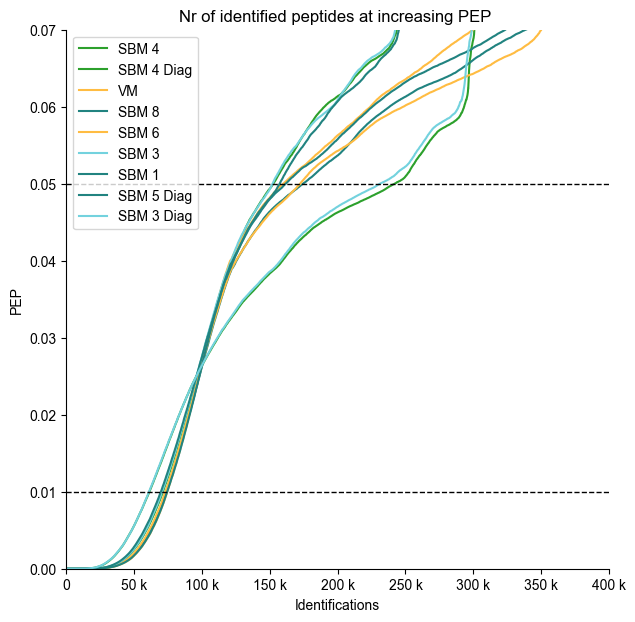

In [24]:
# Create the plot
fig, ax = plt.subplots(figsize=(7, 7))

for group in categories:
    group_data = df_no_sumo[df_no_sumo['Dataset'] == group]
    sorted_df = group_data.sort_values(by='PEP').reset_index(drop=True)
    ax.plot(sorted_df.index, sorted_df['PEP'], 
            color=color_map[group], label=group)

ax.axhline(y=0.01, color='black', linestyle='--', linewidth=1)
ax.axhline(y=0.05, color='black', linestyle='--', linewidth=1)

ax.set_ylim(0, 0.07)
ax.set_xlim(0, 400000)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.xaxis.set_major_formatter(ticker.EngFormatter())

ax.legend(title='Test run')
plt.legend(loc='upper left')

ax.set_title('Nr of identified peptides at increasing PEP ')
ax.set_xlabel('Identifications')
ax.set_ylabel('PEP')
plt.savefig("pep_curve_all_peptides.pdf")

plt.show()